<a href="https://colab.research.google.com/github/radwaelreedy/DEPI_Tech_Journey/blob/main/Assignment_Applying_K-means_For_Image%20/%20Assignment_K_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
from PIL import Image

In [ ]:
np.random.seed(1)

array([[[ 74, 178, 195],
        [ 74, 178, 195],
        [ 74, 178, 195],
        ...,
        [ 89, 183, 206],
        [ 87, 184, 206],
        [ 87, 184, 206]],

       [[ 74, 178, 195],
        [ 74, 178, 195],
        [ 74, 178, 195],
        ...,
        [ 89, 183, 206],
        [ 87, 184, 206],
        [ 87, 184, 206]],

       [[ 74, 178, 195],
        [ 74, 178, 195],
        [ 74, 178, 195],
        ...,
        [ 89, 183, 206],
        [ 87, 184, 206],
        [ 87, 184, 206]],

       ...,

       [[ 71, 174, 194],
        [ 71, 174, 194],
        [ 71, 174, 194],
        ...,
        [ 76, 180, 200],
        [ 76, 180, 200],
        [ 76, 180, 200]],

       [[ 71, 174, 194],
        [ 71, 174, 194],
        [ 71, 174, 194],
        ...,
        [ 76, 180, 200],
        [ 76, 180, 200],
        [ 76, 180, 200]],

       [[ 71, 174, 194],
        [ 71, 174, 194],
        [ 71, 174, 194],
        ...,
        [ 76, 180, 200],
        [ 76, 180, 200],
        [ 76, 180, 200]]], dtype=uint8)
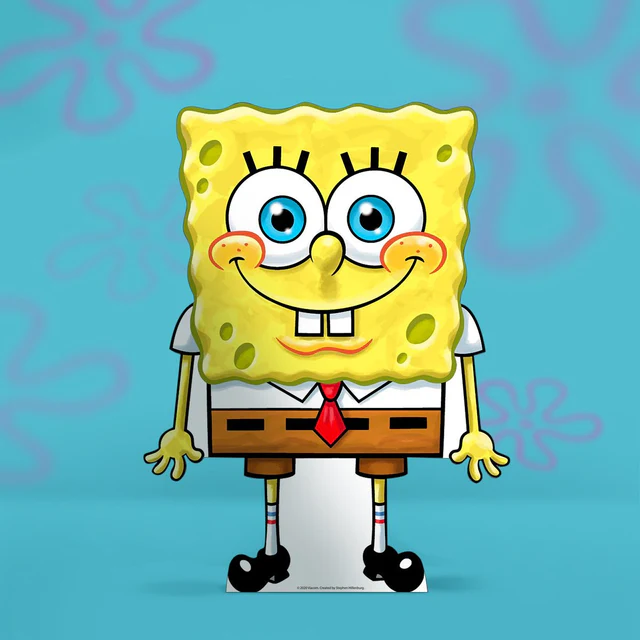

In [ ]:
#load image
#display image
img = plt.imread('/content/spongebob-squarepants-life-sized-cardboard-cutout-standee-799367_640x640.jpg.webp')
img

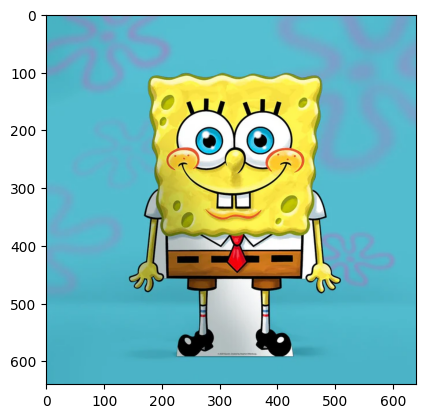

In [ ]:
plt.imshow(img)


In [ ]:
# TODO: print image shape and dtype
img.shape , img.dtype , img.size

((640, 640, 3), dtype('uint8'), 1228800)

In [ ]:
h, w, c = img.shape

In [ ]:
h, w, d = img.shape
datapixel = img.reshape(h*w, d)
print(datapixel)
#Normalize number in the range of (0, 1)
datapixel = datapixel /255
datapixel

[[ 74 178 195]
 [ 74 178 195]
 [ 74 178 195]
 ...
 [ 76 180 200]
 [ 76 180 200]
 [ 76 180 200]]


array([[0.29019608, 0.69803922, 0.76470588],
       [0.29019608, 0.69803922, 0.76470588],
       [0.29019608, 0.69803922, 0.76470588],
       ...,
       [0.29803922, 0.70588235, 0.78431373],
       [0.29803922, 0.70588235, 0.78431373],
       [0.29803922, 0.70588235, 0.78431373]])

In [ ]:
datapixel = datapixel.astype(float)

print(datapixel.shape)  # (H*W, 3)

(409600, 3)


In [ ]:
type(img)

numpy.ndarray

In [ ]:
from sklearn.utils import shuffle
imageArraySample = shuffle(datapixel, random_state = 1)[:1000]
imageArraySample.size  #for RGB 3000, every color 1000


3000

In [ ]:
Kmeans =KMeans(n_clusters = 5, random_state =1 )
Kmeans.fit(datapixel)

KMeans(n_clusters=5, random_state=1)

In [ ]:
labels = Kmeans.predict(datapixel)
labels

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
Kmeans.inertia_

5328.692092449812

In [ ]:
print(Kmeans.cluster_centers_)


[[0.33714599 0.70673796 0.7940268 ]
 [0.05091551 0.04821869 0.03758691]
 [0.94781643 0.88627229 0.30375944]
 [0.88609107 0.9004146  0.87500029]
 [0.62312364 0.46871114 0.13816147]]


In [ ]:
c = Kmeans.cluster_centers_

In [ ]:
def recreateImage (c,labels, w, h, d):
  image = np.zeros((w,h, d))
  labelIndex=0

  for i in range(w):
    for j in range(h):
      image[i][j]=c[labels[labelIndex]]
      labelIndex+=1
  return(image)

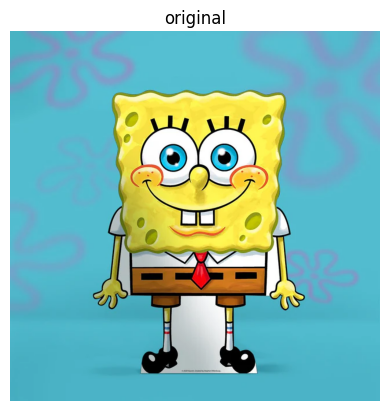

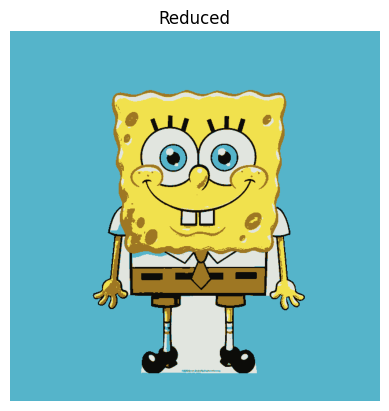

In [ ]:
plt.figure(1)
plt.axis('off')
plt.title("original")
plt.imshow(img)
plt.show()
plt.figure(2)
plt.axis("off")
plt.title("Reduced")
plt.imshow(recreateImage (c,labels, w, h, d))
plt.show()

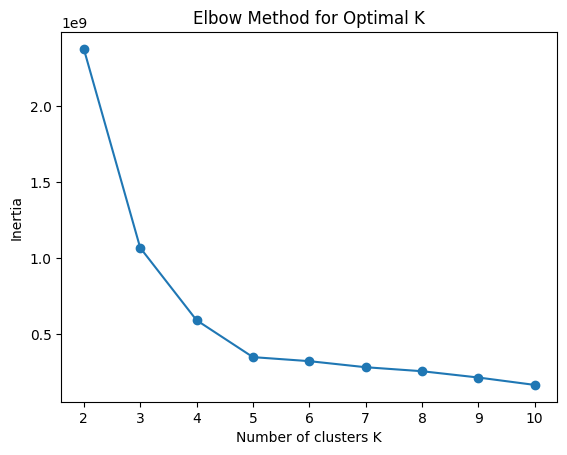

In [ ]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Assume `pixel_colors` is shape (n_pixels, 3) from an image
pixel_colors = img.reshape((-1, 3))

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixel_colors)
    inertias.append(kmeans.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of clusters K')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

1. Which K value would you deploy in production and why?

    5 Clusters depend on elbow method
2. How does image segmentation help product recommendation?

    By segmenting patterns and textures
3. What are the risks of using K-Means for images?

    Noisy pixels can pull centroids away from true regions.
4. How would lighting or background affect clustering?

    Lighting changes pixel colors and intensities, so the same object may be split into different clusters.